In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import time
import numpy as np
import jax
import jax.numpy as jnp
import fdtdx
import pytreeclass as tc
import matplotlib.pyplot as plt
from IPython.display import Video

In [2]:
%matplotlib inline

In [3]:
key = jax.random.PRNGKey(42)
object_list = []
constraints = []

In [4]:
wavelength = 1.55e-6

In [5]:
config = fdtdx.SimulationConfig(
    time=120e-15,
    resolution=50e-9,      
    dtype=jnp.float32,
    courant_factor=0.99,
)

In [6]:
materials = {
    "air": fdtdx.Material(permittivity=1.0, permeability=1.0),
    "core": fdtdx.Material(permittivity=(3.45**2), permeability=1.0),  # silicon-ish
}

In [7]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(10.0e-6, 4.0e-6, 4.0e-6),
    material=materials["air"],
)
object_list.append(volume)

In [8]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, c_list = fdtdx.boundary_objects_from_config(bound_cfg, volume)
constraints.extend(c_list)
object_list.extend(bound_dict.values())

In [9]:
verts_yz = np.array([
    [-0.30e-6, -0.11e-6],
    [ 0.30e-6, -0.11e-6],
    [ 0.22e-6,  0.11e-6],
    [-0.22e-6,  0.11e-6],
], dtype=float)

In [10]:
poly = fdtdx.ExtrudedPolygon(
    name="PolyCore",
    axis=0,  # extrude along x; polygon lies in the other two axes (y,z)
    vertices=verts_yz,
    materials=materials,
    material_name="core",
    partial_real_shape=(6.0e-6, None, None),  # x-length set; y/z from polygon bbox
    color=fdtdx.colors.PINK,
)
object_list.append(poly)

In [11]:
constraints.append(poly.place_at_center(volume))

In [12]:
source = fdtdx.ModePlaneSource(
    mode_index=0,
    filter_pol="te",
    partial_grid_shape=(1, None, None),  # 1 cell in propagation direction (x)
    direction="+",
    wave_character=fdtdx.WaveCharacter(wavelength=wavelength),
    name="ModeSource",
    color=fdtdx.colors.GREEN,
)

In [13]:
object_list.append(source)

In [14]:
constraints.append(
    source.place_relative_to(
        volume,
        axes=0,
        own_positions=-1,
        other_positions=-1,
        margins=1.0e-6,
    )
)

In [15]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=4),  # record every 4 steps
    exact_interpolation=True,
    num_video_workers=8,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))

In [16]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

<Figure size 700x500 with 0 Axes>

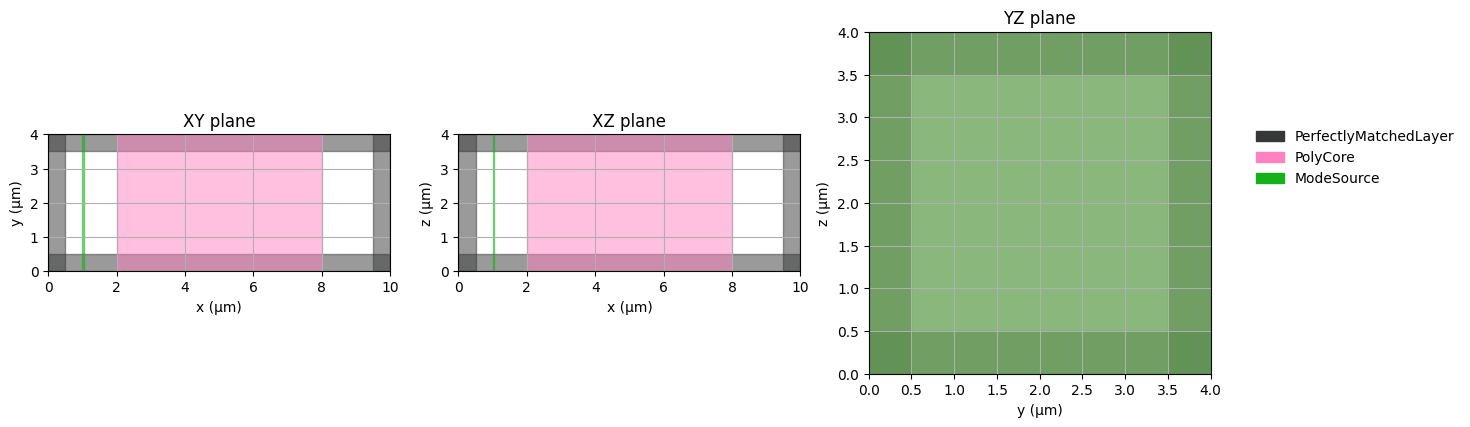

In [17]:
plt.figure(figsize=(7, 5))
fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()

In [18]:
def sim_fn(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(arrays=arrays, objects=new_objects, config=config, key=key)
    _, arrays_out = final_state
    return arrays_out

In [19]:
start = time.time()
jitted = jax.jit(sim_fn).lower(params, arrays, key).compile()
print("Compilation time (s):", time.time() - start)

Compilation time (s): 2.52717661857605


In [20]:
key, runkey = jax.random.split(key)
start = time.time()
new_arrays = jitted(params, arrays, runkey)
print("Simulation runtime (s):", time.time() - start)

Simulation runtime (s): 3.1647191047668457


In [21]:
video_path = objects["Video"].draw_plot(new_arrays.detector_states["Video"])
print(video_path)
Video(list(video_path.values())[0], embed=True, width=720)

{'sliced_video': '/tmp/tmp80dgdomp.mp4'}
